# Decision-aware adaptive replication

This notebook turns the Bayesian timing posterior into a constrained R&D design question:

> **Which product should receive the next paired Early/Late block if the goal is to reduce uncertainty about the timing decision?**

The comparison deliberately separates generic parameter information from information about the sign of the effect. The latter is the actual Early-versus-Late choice.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from crop_protection_ps.adaptive_demo import run_adaptive_demo

summary = run_adaptive_demo(ROOT)
summary["initial_acquisition"]

{'decision_aware_first_product': 'Revus',
 'decision_sign_eig_nats': 0.010584391852149766,
 'prob_wrong_timing_if_act_now': 0.09458276556919354,
 'parameter_information_first_product': 'Curzate',
 'interpretation': 'Parameter-centric and decision-centric design select different first experiments.'}

## Initial acquisition ranking

For product \(p\), the current posterior is approximated by

\[
\theta_p\mid D \approx N(\mu_p,v_p),
\]

where \(\theta_p\) is the Late-minus-Early effect on \(\sqrt{AUDPC}\). A positive value favours Early timing.

The decision criterion uses the expected reduction in entropy of \(\mathbf 1(\theta_p>0)\).

In [2]:
acquisition = pd.read_csv(ROOT / "results/real_hop_trial/adaptive_design/initial_acquisition_ranking.csv")
acquisition

,treatment,posterior_mean_delta_sqrt_audpc,posterior_sd,paired_observation_sd,prob_late_greater_disease,prob_wrong_timing_if_act_now,sign_entropy_nats,parameter_eig_nats,decision_sign_eig_nats,bayes_regret_sqrt_audpc,decision_eig_rank,parameter_eig_rank
0,Revus,0.844685,0.643299,2.480378,0.905417,0.094583,0.313014,0.032550,0.010584,0.028485,1,2
1,Curzate,1.411631,0.630478,2.093492,0.987422,0.012578,0.067539,0.043409,0.003572,0.002756,2,1
2,FungiPhi,1.315930,0.632131,3.302302,0.981317,0.018683,0.092870,0.017993,0.002021,0.004300,3,3
3,Ranman,1.343266,0.629641,3.600008,0.983553,0.016447,0.083867,0.015066,0.001546,0.003712,4,4
4,Presidio,1.737739,0.683913,5.113145,0.994471,0.005529,0.034251,0.008866,0.000400,0.001207,5,5


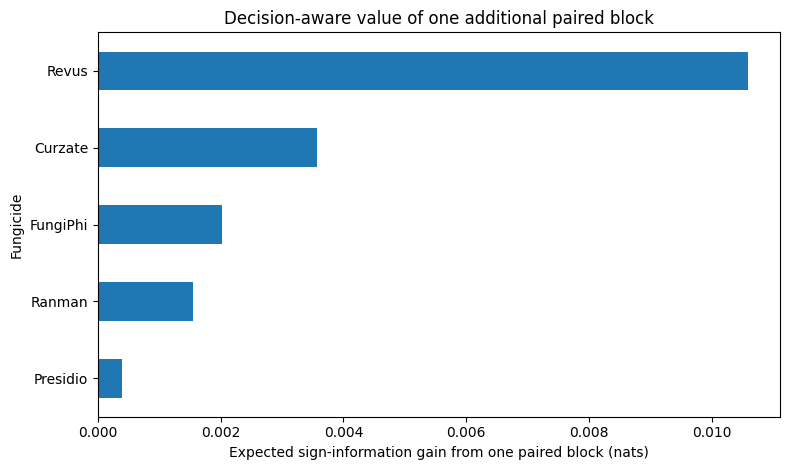

In [3]:
ax = acquisition.sort_values("decision_sign_eig_nats").plot.barh(
    x="treatment",
    y="decision_sign_eig_nats",
    legend=False,
    figsize=(8, 4.8),
)
ax.set_xlabel("Expected sign-information gain from one paired block (nats)")
ax.set_ylabel("Fungicide")
ax.set_title("Decision-aware value of one additional paired block")
plt.tight_layout()

The key contrast is intentional:

\[
\text{parameter information}\Rightarrow\text{Curzate first},
\qquad
\text{decision information}\Rightarrow\text{Revus first}.
\]

Curzate offers efficient refinement of a continuous effect whose sign is already quite certain. Revus carries substantially more probability that the current Early/Late choice is wrong.

## Pre-posterior policy evaluation

Future paired-block results are simulated from the current posterior predictive distribution. Three policies are compared under the same budgets: uniform allocation, continuous-parameter information gain, and decision-sign information gain.

In [4]:
metrics = pd.read_csv(ROOT / "results/real_hop_trial/adaptive_design/policy_budget_metrics.csv")
metrics[[
    "policy",
    "budget_paired_blocks",
    "mean_sign_entropy_nats",
    "mean_bayes_regret_sqrt_audpc",
    "mean_expected_wrong_timing_decisions",
]]

,policy,budget_paired_blocks,mean_sign_entropy_nats,mean_bayes_regret_sqrt_audpc,mean_expected_wrong_timing_decisions
0,decision_eig,0,0.591541,0.040459,0.147820
1,decision_eig,5,0.548463,0.040064,0.147560
2,decision_eig,10,0.515144,0.037328,0.142902
3,decision_eig,15,0.490430,0.034650,0.138566
4,decision_eig,20,0.469397,0.031974,0.133650
5,parameter_eig,0,0.591541,0.040459,0.147820
6,parameter_eig,5,0.569525,0.040405,0.147764
7,parameter_eig,10,0.546084,0.040427,0.147962
8,parameter_eig,15,0.521758,0.039874,0.147375
9,parameter_eig,20,0.507205,0.039011,0.146406


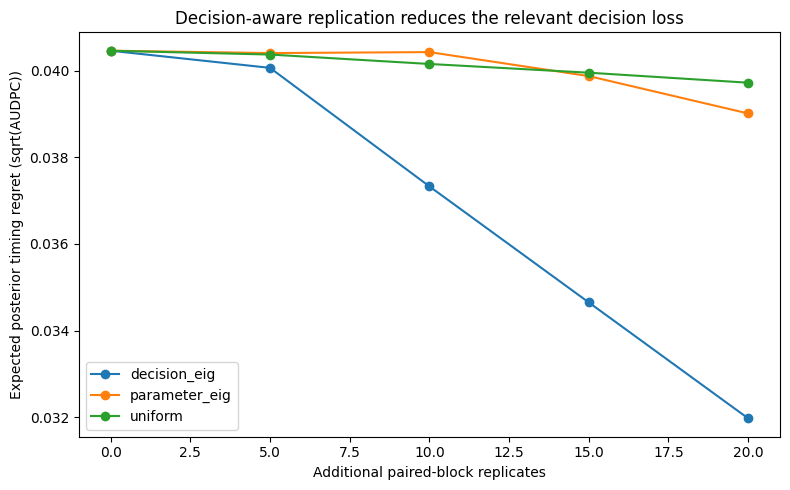

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for policy, group in metrics.groupby("policy"):
    group = group.sort_values("budget_paired_blocks")
    ax.plot(
        group["budget_paired_blocks"],
        group["mean_bayes_regret_sqrt_audpc"],
        marker="o",
        label=policy,
    )
ax.set_xlabel("Additional paired-block replicates")
ax.set_ylabel("Expected posterior timing regret (sqrt(AUDPC))")
ax.set_title("Decision-aware replication reduces the relevant decision loss")
ax.legend()
plt.tight_layout()

In [6]:
budget_15 = metrics.loc[metrics["budget_paired_blocks"] == 15].copy()
budget_15[[
    "policy",
    "mean_sign_entropy_nats",
    "mcse_sign_entropy_nats",
    "mean_bayes_regret_sqrt_audpc",
    "mcse_bayes_regret_sqrt_audpc",
]]

,policy,mean_sign_entropy_nats,mcse_sign_entropy_nats,mean_bayes_regret_sqrt_audpc,mcse_bayes_regret_sqrt_audpc
3,decision_eig,0.490430,0.002248,0.034650,0.000377
8,parameter_eig,0.521758,0.002011,0.039874,0.000374
13,uniform,0.541704,0.001735,0.039952,0.000279


At 15 additional paired blocks, the Decision-EIG policy reduces expected Bayes regret by about **13.3%** and sign entropy by about **9.5%** relative to uniform replication. These are pre-posterior quantities under the current model, not claims about agronomic performance in a new population.

## Where the budget goes

The fractional values below are averages across simulated future data paths. Every realised sequential experiment allocates integer paired blocks.

In [7]:
allocations = pd.read_csv(ROOT / "results/real_hop_trial/adaptive_design/mean_replication_allocations.csv")
allocations.loc[allocations["budget_paired_blocks"] == 15]

,policy,budget_paired_blocks,Curzate,FungiPhi,Presidio,Ranman,Revus
9,decision_eig,15,2.0488,0.9686,0.0,0.323,11.6596
10,parameter_eig,15,9.0000,0.0000,0.0,0.000,6.0000
11,uniform,15,3.0000,3.0000,3.0,3.000,3.0000


## Evidence gate from the environment analysis

The same-year untreated sentinel remains useful as an in-season measure of realised disease pressure. However, v0.4 did **not** validate product-by-sentinel timing interactions. The adaptive design therefore does not force those interactions back into the model merely because they would make the decision surface more elaborate.

\[
\text{useful environment state}\not\Rightarrow\text{identified treatment-by-environment interaction}.
\]

That constraint is part of the design, not a missing feature.

## Interpretation

The project now closes a complete predictive-science loop: designed experiment → hierarchical evidence → transportability test → uncertainty → adaptive next experiment. The point is not that one policy is universally optimal. It is that the experimental-design objective is explicitly tied to the scientific decision and can be audited before resources are spent.